# 单轨迹 $\theta_t$ 估计方法探索（基于 SPINN）

本 notebook 接着 `SPINN_OU_demo.ipynb`，专门研究一个问题：**只用单条轨迹**（不跨轨迹平均，每条轨迹的平衡位置 $\mu_i$ 未知且各不相同），怎样更好地估计时变的均值回复速率 $\theta_t$？

$$
\mathrm{d}X^{(i)}_t = \theta_t\,(\mu_i - X^{(i)}_t)\,\mathrm{d}t + \sigma_t\,\mathrm{d}W^{(i)}_t
$$

- **基线**：`SPINN_OU_demo.ipynb` 第 10.3 节的 **SPINN + OLS 单轨迹联合校准**（下文简称“融合”）。
- **候选方法**：窗口大小调节、时变系数卡尔曼平滑（用 SPINN 的扩散估计作为观测噪声）、SPINN 引导的自适应卡尔曼、集成平均，以及相应的消融实验。
- **评估**：全新模拟的独立测试轨迹（每个情景 32 条，$\mu_i$ 各不相同），另外考察轨迹长度的影响。

> **运行前提**：先完整运行一次 `SPINN_OU_demo.ipynb`，它会把训练好的 3 个网络保存在 `model_dir/ou_demo/`。本 notebook 只加载模型做推断，不重新训练，在 4 核 CPU 上约 2–3 分钟即可跑完。

## 0. 环境与配置

网络配置必须与 `SPINN_OU_demo.ipynb` 训练时一致（`QUICK = True` 的设置）。

In [1]:
import os, sys, time, types, argparse, warnings, itertools
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('.')
while not os.path.exists(os.path.join(REPO_ROOT, 'TrainJumpSDEsTransform.py')):
    parent = os.path.dirname(REPO_ROOT)
    if parent == REPO_ROOT:
        raise FileNotFoundError('请把 notebook 放在 SPINN 仓库内运行')
    REPO_ROOT = parent
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    import pkg_resources  # noqa: F401
except ImportError:  # 新版 setuptools 已移除 pkg_resources，仓库的 robust_loss_pytorch 需要它
    _shim = types.ModuleType('pkg_resources')
    def _resource_stream(package, resource):
        return open(os.path.join(os.path.dirname(sys.modules[package].__file__), resource), 'rb')
    _shim.resource_stream = _resource_stream
    sys.modules['pkg_resources'] = _shim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.ndimage import uniform_filter1d

from model.JumpSDEsTrans import JumpSDEsTransformer
from TrainJumpSDEsTransform import (DatasetTracks, generate_dataset_torch, train_sigma, train_velocity,
                                    transform, load)
from utils.csv2npy import v_normalize_batch_encoder

torch.set_num_threads(os.cpu_count())
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

C_TRUE = '#3a3a38'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 1.6,
                     'font.size': 9, 'legend.frameon': False, 'axes.unicode_minus': False})

# 与 SPINN_OU_demo.ipynb（QUICK = True）相同的网络配置
cfg = argparse.Namespace(
    epochs=12, epochs_VDt=6, batch_size=20, lr=1e-3, seed=0, clip_grad=5.0, scale=0.375, warmup_steps=100,
    RESUME=False, default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32,
    d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True, in_dim=2, out_dim=2,
    pred_length=50, encoder_length=50, beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0,
    noise_adding=0.0, sample_rates=1.0, sample_nums=0,
    dload='./model_dir/ou_demo', save_name='ou-demo', model_name='ou-demo.pth', device=DEVICE,
)
for f in ['ou-demo.pth', 'ou-demo-var.pth', 'ou-demo-vel.pth']:
    if not os.path.exists(os.path.join(cfg.dload, f)):
        raise FileNotFoundError(f'找不到 {cfg.dload}/{f}，请先完整运行 SPINN_OU_demo.ipynb')

model = JumpSDEsTransformer(in_dim=cfg.in_dim, out_dim=cfg.in_dim, encoding_len=cfg.encoder_length,
                            h_dim=cfg.h_dim, default_enc_nn=cfg.default_enc_nn, hidden_dim=cfg.hidden_size,
                            layers=cfg.layers, d_model=cfg.d_model, n_head=cfg.n_heads, layers_enc=cfg.enc_layers,
                            dropout=cfg.dropout, device=cfg.device).to(cfg.device)
load(model, cfg.dload, cfg.model_name)
L_ENC, L_PRED = cfg.encoder_length, cfg.pred_length
WIN = L_ENC + L_PRED
print('模型已加载 | device:', DEVICE)

模型已加载 | device: cpu


## 1. 独立测试数据：$\mu_i$ 各不相同的时变 OU 轨迹

模拟参数与 `SPINN_OU_demo.ipynb` 相同（$\Delta=0.02$、每条轨迹 1000 帧、6 种 $\theta_t/\sigma_t$ 组合），使用精确离散化：

$$
X_{n+1} = \mu_i + (X_n-\mu_i)\,e^{-\theta_n\Delta} + \sigma_n\sqrt{\tfrac{1-e^{-2\theta_n\Delta}}{2\theta_n}}\;\xi_n .
$$

这里用**新的随机种子**生成每个情景 32 条轨迹。它们既没有参与训练，也没有在 `SPINN_OU_demo.ipynb` 里被用来挑选方法。每条轨迹的平衡位置 $\mu_i = (2,-1) + \delta_i$，$\delta_i\sim\mathcal N(0, 1^2)$。

In [2]:
DT, T_LEN, N_EVAL = 0.02, 1000, 32
MU0 = np.array([2.0, -1.0])
t_grid = np.arange(T_LEN) * DT
T_END = t_grid[-1] + DT
square_wave = lambda t, period: (np.floor(t / (period / 2)) % 2).astype(float)

SCENARIOS = {
    'A 常数基准':        dict(en='A: constant θ, σ',         theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0 * t),
    'B σ 阶跃':          dict(en='B: σ step',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: np.where(t < T_END / 2, 0.6, 1.5)),
    'C σ 正弦':          dict(en='C: σ sine',                theta=lambda t: 4.0 + 0 * t, sigma=lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / 10)),
    'D θ 线性增加':      dict(en='D: θ ramp',                theta=lambda t: 1.0 + 9.0 * t / T_END, sigma=lambda t: 1.0 + 0 * t),
    'E θ 正弦 + σ 线性': dict(en='E: θ sine + σ ramp',       theta=lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 8), sigma=lambda t: 0.5 + 1.0 * t / T_END),
    'F θ/σ 反相切换':     dict(en='F: θ/σ anti-phase switch', theta=lambda t: 2.0 + 6.0 * square_wave(t, 10), sigma=lambda t: 1.4 - 0.7 * square_wave(t, 10)),
}
names = list(SCENARIOS)
EN = {k: v['en'] for k, v in SCENARIOS.items()}

def simulate_ou(theta_fn, sigma_fn, n_tracks, rng, mu_spread=1.0):
    th, sg = theta_fn(t_grid), sigma_fn(t_grid)
    a = np.exp(-th * DT)
    sd = sg * np.sqrt((1 - a ** 2) / (2 * th))
    mu = MU0 + mu_spread * rng.standard_normal((n_tracks, 1, 2))          # 每条轨迹自己的 μ_i
    X = np.empty((n_tracks, T_LEN, 2))
    X[:, 0] = mu[:, 0] + sg[0] / np.sqrt(2 * th[0]) * rng.standard_normal((n_tracks, 2))
    for n in range(T_LEN - 1):
        X[:, n + 1] = mu[:, 0] + (X[:, n] - mu[:, 0]) * a[n] + sd[n] * rng.standard_normal((n_tracks, 2))
    return dict(X=X, mu=mu, theta=th, sigma=sg, sigma_eff=sd / np.sqrt(DT))

rng = np.random.default_rng(2025)
DATA = {name: simulate_ou(sc['theta'], sc['sigma'], N_EVAL, rng) for name, sc in SCENARIOS.items()}
print({k: v['X'].shape for k, v in DATA.items()})

{'A 常数基准': (32, 1000, 2), 'B σ 阶跃': (32, 1000, 2), 'C σ 正弦': (32, 1000, 2), 'D θ 线性增加': (32, 1000, 2), 'E θ 正弦 + σ 线性': (32, 1000, 2), 'F θ/σ 反相切换': (32, 1000, 2)}


## 2. SPINN 推断

与 `SPINN_OU_demo.ipynb` 第 3、6 节完全相同：先切成 regular + head 片段并归一化，再依次调用仓库的 `transform`、`train_sigma(is_train=False)`、`train_velocity(is_train=False)`，最后反归一化并拼回整条轨迹。得到每条轨迹、每一帧的漂移 $v^{(1)}$ 和扩散 $s^{(1)}$。

In [3]:
def segment(arr, is_head=False):
    if is_head:
        arr = np.concatenate([np.repeat(arr[:, :1], L_PRED, axis=1), arr[:, :-L_PRED]], axis=1)
    starts = np.arange(0, arr.shape[1] - WIN + 1, WIN)
    return np.concatenate([arr[:, s:s + WIN][:, None] for s in starts], axis=1).reshape(-1, WIN, *arr.shape[2:])

def build_segments(X):
    N = X.shape[0]
    frame = np.broadcast_to(np.arange(T_LEN), (N, T_LEN))
    track = np.broadcast_to(np.arange(N)[:, None], (N, T_LEN))
    out = {}
    for kind, head in [('regular', False), ('head', True)]:
        seg_norm, s = v_normalize_batch_encoder(segment(X, head), encoder_len=L_ENC)
        out[kind] = dict(x=seg_norm.astype(np.float32), norm=s, frame=segment(frame, head), track=segment(track, head))
    return out

def spinn_infer(seg_x):
    ds = DatasetTracks(seg_x, cfg, sample_rate=1.0)
    _, test_ds = generate_dataset_torch(ds, seed=cfg.seed, train_prob=1e-6)
    _, y1, _, _ = transform(test_ds, model, cfg)
    s_ds, model_s = train_sigma(test_ds, model, cfg, is_train=False)
    _, s1, _, _ = transform(s_ds, model_s, cfg)
    v_ds, model_v = train_velocity(test_ds, model, cfg, is_train=False)
    _, v1, _, _ = transform(v_ds, model_v, cfg)
    tb = lambda a: a.transpose(1, 0, 2)[:, -L_PRED:]
    return dict(v1=tb(v1), s1=tb(s1))

def infer_tracks(X):
    segs, N = build_segments(X), X.shape[0]
    full = {k: np.full((N, T_LEN, 2), np.nan) for k in ['v1', 's1']}
    for kind in ['regular', 'head']:
        seg = segs[kind]
        o = spinn_infer(seg['x'])
        s = seg['norm'].reshape(1, 1, 2)
        fr, tr = seg['frame'][:, L_ENC:], seg['track'][:, L_ENC:]
        full['v1'][tr, fr] = o['v1'] * s
        full['s1'][tr, fr] = o['s1'] * s ** 2
    return full

t0 = time.time()
RES = {name: infer_tracks(DATA[name]['X']) for name in names}
print(f'SPINN 推断完成，用时 {time.time() - t0:.0f}s')

SPINN 推断完成，用时 46s


## 3. 评估指标

所有指标都在**单条轨迹**上计算，再取 32 条轨迹的中位数：

- **θ MRE**：$\frac{1}{T}\sum_n |\hat\theta^{(i)}_n-\theta_n|/\theta_n$，衡量整体精度（包括绝对水平）；
- **corr(θ̂, θ)**：单轨迹估计与真值时间曲线的相关系数，衡量**趋势**是否正确（仅对 $\theta$ 随时间变化的 D、E、F）；
- **corr(θ̂, σ)**：与名义 $\sigma_t$ 的相关系数，是**混淆检查**（B、C 中真实 $\theta$ 恒定，理想值为 0）。

另外给出 6 个情景 θ MRE 的平均值作为总体排名。

In [4]:
def _corr_rows(a, b):
    a = a - a.mean(axis=1, keepdims=True); b = b - b.mean()
    return (a @ b) / (np.sqrt((a ** 2).sum(axis=1)) * np.sqrt((b ** 2).sum()) + 1e-12)

def evaluate(th, name, t_slice=slice(None)):
    d = DATA[name]
    th_t, sg = d['theta'][t_slice], d['sigma'][t_slice]
    th = th[:, t_slice]
    return {'θ MRE': np.median(np.mean(np.abs(th - th_t) / th_t, axis=1)),
            'corr(θ̂,θ)': np.median(_corr_rows(th, th_t)) if th_t.std() > 1e-9 else np.nan,
            'corr(θ̂,σ) [混淆]': np.median(_corr_rows(th, sg)) if sg.std() > 1e-9 else np.nan}

EST = {name: {} for name in names}      # EST[情景][方法] = θ̂ (N,T)

def score_table(methods, t_slice=slice(None)):
    rows = [dict(情景=n, 方法=m, **evaluate(EST[n][m], n, t_slice)) for n in names for m in methods]
    return pd.DataFrame(rows)

def mre_pivot(methods, t_slice=slice(None)):
    df = score_table(methods, t_slice).pivot(index='情景', columns='方法', values='θ MRE')[methods]
    df.loc['6 个情景平均'] = df.mean()
    return df

## 4. 候选方法

### 4.0 共同工具

所有方法最后都是先估计局部回归斜率 $k$（$\Delta X \approx c + kX$，$k=-(1-e^{-\theta\Delta})$），再换算 $\hat\theta=-\ln(1+\hat k)/\Delta$。局部截距 $c$ 吸收每条轨迹自己的 $\mu_i$。

滑动窗口 OLS 的斜率有 Kendall 小样本偏差，校正公式为

$$
\hat\varphi_c = \frac{W\hat\varphi+1}{W-3},\qquad \hat\varphi = 1+\hat k .
$$

In [5]:
_roll = lambda z, W: uniform_filter1d(z, W, axis=1, mode='nearest')
k2theta = lambda k: -np.log(np.clip(1 + k, 1e-6, None)) / DT
kendall = lambda k, W: (W * (1 + k) + 1) / (W - 3) - 1

def rolling_k(y, X, W):
    """单轨迹滑动窗口回归 y = c + kX（每维独立、带截距），两维斜率平均 -> (N,T)"""
    mx, my = _roll(X, W), _roll(y, W)
    return ((_roll(X * y, W) - mx * my) / (_roll(X * X, W) - mx ** 2)).mean(axis=2)

def spinn_sigma(s1):
    """SPINN 单轨迹 σ̂(t)，25 帧平滑 -> (N,T)"""
    return np.sqrt(_roll(s1.mean(axis=2, keepdims=True), 25)[..., 0] / DT)

INC = {name: np.diff(DATA[name]['X'], axis=1, append=DATA[name]['X'][:, -1:]) for name in names}
SIG = {name: spinn_sigma(RES[name]['s1']) for name in names}

### 4.1 参照方法（来自 `SPINN_OU_demo.ipynb`）

| 方法 | 做法 |
|---|---|
| `SPINN` | 对 SPINN 漂移 $v^{(1)}$ 做滑动窗口回归（$W=100$） |
| `OLS` | 对原始位移 $\Delta X$ 做滑动窗口回归，Kendall 校正（$W=100$） |
| **`融合 (基线)`** | 每条轨迹内拟合 $k^{\text{OLS}} \sim 1 + k^{\text{SPINN}} + \hat\sigma^{\text{SPINN}}$，用拟合值并做 Kendall 校正 |

In [6]:
def fused_k(X, v1, sig, W=100):
    k_ols, k_sp = rolling_k(np.diff(X, axis=1, append=X[:, -1:]), X, W), rolling_k(v1, X, W)
    out = np.empty_like(k_ols)
    for i in range(X.shape[0]):
        M = np.column_stack([np.ones(X.shape[1]), k_sp[i], sig[i]])
        out[i] = M @ np.linalg.lstsq(M, k_ols[i], rcond=None)[0]
    return kendall(out, W)

for name in names:
    X, v1 = DATA[name]['X'], RES[name]['v1']
    EST[name]['SPINN'] = k2theta(rolling_k(v1, X, 100))
    EST[name]['OLS'] = k2theta(kendall(rolling_k(INC[name], X, 100), 100))
    EST[name]['融合 (基线)'] = k2theta(fused_k(X, v1, SIG[name], 100))

mre_pivot(['SPINN', 'OLS', '融合 (基线)']).style.format('{:.3f}')

方法,SPINN,OLS,融合 (基线)
情景,,,
A 常数基准,0.412,0.440,0.280
B σ 阶跃,0.347,0.414,0.229
C σ 正弦,0.358,0.442,0.236
D θ 线性增加,0.502,0.495,0.391
E θ 正弦 + σ 线性,0.447,0.370,0.391
F θ/σ 反相切换,0.408,0.548,0.357
6 个情景平均,0.412,0.452,0.314


### 4.2 方法一：调节窗口大小 $W$

滑动窗口的大小决定了偏差与方差的权衡：窗口大，噪声小，但对 $\theta_t$ 的快速变化反应慢。这里对融合方法扫描 $W\in\{50,100,200,300\}$。

In [7]:
W_LIST = [50, 100, 200, 300]
for name in names:
    for W in W_LIST:
        EST[name][f'融合 W={W}'] = k2theta(fused_k(DATA[name]['X'], RES[name]['v1'], SIG[name], W))
mre_pivot([f'融合 W={W}' for W in W_LIST]).style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb')

方法,融合 W=50,融合 W=100,融合 W=200,融合 W=300
情景,,,,
A 常数基准,0.350,0.280,0.196,0.175
B σ 阶跃,0.279,0.229,0.189,0.188
C σ 正弦,0.339,0.236,0.150,0.152
D θ 线性增加,0.532,0.391,0.296,0.272
E θ 正弦 + σ 线性,0.466,0.391,0.346,0.393
F θ/σ 反相切换,0.431,0.357,0.351,0.439
6 个情景平均,0.399,0.314,0.255,0.270


### 4.3 方法二：时变系数卡尔曼平滑（KF-TVP）

滑动窗口需要人为选定 $W$，而且窗口内所有帧权重相同。更有原则的做法是把斜率 $k_n$ 当成一个缓慢变化的**隐状态**，写成线性高斯状态空间模型：

$$
\underbrace{\begin{pmatrix}c_{x,n+1}\\ c_{y,n+1}\\ k_{n+1}\end{pmatrix}}_{s_{n+1}} = s_n + w_n,\qquad w_n\sim\mathcal N\!\big(0,\ \mathrm{diag}(q\bar v,\ q\bar v,\ q)\big),
$$

$$
\Delta X_{n,d} = c_{d,n} + k_n\,\tilde X_{n,d} + e_{n,d},\qquad e_{n,d}\sim\mathcal N\big(0,\ \hat s^{(1)}_{n,d}\big),\quad d\in\{x,y\},
$$

其中 $\tilde X$ 是减去轨迹均值的位置，$\bar v$ 是 $\tilde X^2$ 的均值（让截距与斜率的变化幅度匹配）。

- **观测噪声直接使用 SPINN 的逐帧扩散估计 $\hat s^{(1)}_{n,d}$**，这正是 SPINN 在单轨迹上最可靠的输出。这样 $\sigma_t$ 的变化被正确地计入噪声，而不会被误读为 $\theta$ 的变化。
- 用卡尔曼滤波加 RTS 平滑器（前向 + 后向）得到每一帧的 $\hat k_n$，两个维度共享同一个 $k_n$。
- 平滑强度 $q$ 在网格 $10^{-10}\sim10^{-4}$ 上**对每条轨迹单独**用边际似然（预测误差分解）选择，不使用任何真值，完全自监督。$q$ 很小时 $\hat k$ 近似为常数；$q$ 大时能跟上快速变化。

**消融**：把观测噪声换成常数（整条轨迹增量的方差），即 `KF (常数噪声)`，用来检验 SPINN 扩散估计的贡献。

In [8]:
def kalman_tvp(X, R, QN):
    """时变系数回归的卡尔曼滤波 + RTS 平滑（对轨迹 × 超参数组合批量向量化）
    X: (N,T,2) 位置；R: (N,T,2) 观测噪声方差；QN: (N,G,T) 每个超参数组合、每一步 k 的过程噪声方差
    返回：平滑后的 k (N,G,T)，对数边际似然 (N,G)"""
    N, T, _ = X.shape; G = QN.shape[1]; B = N * G
    Xc = X - X.mean(axis=1, keepdims=True)
    y, Xo, Ro = np.diff(X, axis=1), Xc[:, :-1], R[:, :-1]
    Xb, yb, Rb, qb = np.repeat(Xo, G, 0), np.repeat(y, G, 0), np.repeat(Ro, G, 0), QN.reshape(B, T)
    vx = np.repeat((Xc ** 2).mean(axis=(1, 2)), G)
    m = np.zeros((B, 3)); m[:, 2] = np.repeat((Xo * y).sum(axis=(1, 2)) / (Xo ** 2).sum(axis=(1, 2)), G)
    P = np.zeros((B, 3, 3)); P[:, 0, 0] = P[:, 1, 1] = 0.05 * vx + 1e-6; P[:, 2, 2] = 0.05 ** 2
    Tn = T - 1
    mf, mp = np.zeros((B, Tn, 3)), np.zeros((B, Tn, 3))
    Pf, Pp = np.zeros((B, Tn, 3, 3)), np.zeros((B, Tn, 3, 3))
    ll = np.zeros(B)
    H = np.zeros((B, 2, 3)); H[:, 0, 0] = H[:, 1, 1] = 1
    for n in range(Tn):
        P = P.copy(); P[:, 2, 2] += qb[:, n]; P[:, 0, 0] += qb[:, n] * vx; P[:, 1, 1] += qb[:, n] * vx
        mp[:, n], Pp[:, n] = m, P
        H[:, 0, 2], H[:, 1, 2] = Xb[:, n, 0], Xb[:, n, 1]
        Sm = np.einsum('bij,bjk,blk->bil', H, P, H); Sm[:, 0, 0] += Rb[:, n, 0]; Sm[:, 1, 1] += Rb[:, n, 1]
        v = yb[:, n] - np.einsum('bij,bj->bi', H, m)
        Si = np.linalg.inv(Sm)
        K = np.einsum('bij,bkj,bkl->bil', P, H, Si)
        m = m + np.einsum('bij,bj->bi', K, v)
        P = P - np.einsum('bij,bjk,bkl->bil', K, H, P)
        ll += -0.5 * (np.log(np.linalg.det(Sm)) + np.einsum('bi,bij,bj->b', v, Si, v))
        mf[:, n], Pf[:, n] = m, P
    ms = mf.copy()
    for n in range(Tn - 2, -1, -1):                    # RTS 平滑
        C = np.einsum('bij,bkj->bik', Pf[:, n], np.linalg.inv(Pp[:, n + 1]))
        ms[:, n] = mf[:, n] + np.einsum('bij,bj->bi', C, ms[:, n + 1] - mp[:, n + 1])
    k = ms[:, :, 2].reshape(N, G, Tn)
    return np.concatenate([k, k[:, :, -1:]], axis=2), ll.reshape(N, G)

Q_GRID = np.logspace(-10, -4, 13)

def kf_select(X, R, QN):
    """对每条轨迹按边际似然选最优超参数，返回 k (N,T) 和所选下标"""
    k, ll = kalman_tvp(X, R, QN)
    best = ll.argmax(axis=1)
    return k[np.arange(X.shape[0]), best], best

t0 = time.time()
Q_CHOSEN = {}
for name in names:
    X, s1 = DATA[name]['X'], RES[name]['s1']
    QN = np.broadcast_to(Q_GRID[None, :, None], (N_EVAL, len(Q_GRID), T_LEN))
    k, best = kf_select(X, _roll(s1, 25), QN)
    EST[name]['KF (SPINN 噪声)'] = k2theta(k)
    Q_CHOSEN[name] = Q_GRID[best]
    R_const = np.broadcast_to(INC[name].var(axis=1, keepdims=True), X.shape)
    EST[name]['KF (常数噪声)'] = k2theta(kf_select(X, R_const, QN)[0])
print(f'卡尔曼平滑完成，用时 {time.time() - t0:.0f}s')
print('每个情景所选 q 的中位数：', {EN[n]: f'{np.median(Q_CHOSEN[n]):.0e}' for n in names})

score_table(['融合 (基线)', 'KF (SPINN 噪声)', 'KF (常数噪声)']).set_index(['情景', '方法']).style.format('{:.3f}', na_rep='—')

卡尔曼平滑完成，用时 16s
每个情景所选 q 的中位数： {'A: constant θ, σ': '2e-08', 'B: σ step': '1e-10', 'C: σ sine': '1e-10', 'D: θ ramp': '3e-06', 'E: θ sine + σ ramp': '2e-07', 'F: θ/σ anti-phase switch': '1e-05'}


### 4.4 方法三：SPINN 引导的自适应卡尔曼

固定的 $q$ 意味着 $\theta$ 在任何时刻变化的难易程度都一样，这不利于跟踪突变（情景 F）。想法是**让 SPINN 告诉卡尔曼“什么时候在变”**：用融合估计的变化率调节每一步的过程噪声，

$$
q_n = q_0 + \lambda\,\Big(\frac{\mathrm d \bar k^{\text{fuse}}_n}{\mathrm d n}\Big)^2 ,
$$

其中 $\bar k^{\text{fuse}}$ 是 25 帧平滑后的融合斜率。$(q_0,\lambda)$ 在 $6\times6$ 网格上对每条轨迹用边际似然选择；$\lambda=0$ 时退化为普通 KF-TVP。

In [9]:
Q0_GRID, LAM_GRID = np.logspace(-10, -5, 6), np.array([0, 1, 10, 100, 1e3, 1e4])
COMBOS = list(itertools.product(Q0_GRID, LAM_GRID))
t0 = time.time()
LAM_CHOSEN = {}
for name in names:
    X, s1 = DATA[name]['X'], RES[name]['s1']
    kf = fused_k(X, RES[name]['v1'], SIG[name], 100)
    g = np.gradient(_roll(kf, 25), axis=1) ** 2
    QN = np.stack([q0 + lam * g for q0, lam in COMBOS], axis=1)
    k, best = kf_select(X, _roll(s1, 25), QN)
    EST[name]['KF (SPINN 引导)'] = k2theta(k)
    LAM_CHOSEN[name] = np.array([COMBOS[b][1] for b in best])
print(f'完成，用时 {time.time() - t0:.0f}s')
print('λ > 0 被选中的轨迹比例：', {EN[n]: f'{np.mean(LAM_CHOSEN[n] > 0):.0%}' for n in names})
mre_pivot(['KF (SPINN 噪声)', 'KF (SPINN 引导)']).style.format('{:.3f}')

完成，用时 22s
λ > 0 被选中的轨迹比例： {'A: constant θ, σ': '31%', 'B: σ step': '22%', 'C: σ sine': '16%', 'D: θ ramp': '66%', 'E: θ sine + σ ramp': '25%', 'F: θ/σ anti-phase switch': '66%'}


方法,KF (SPINN 噪声),KF (SPINN 引导)
情景,,
A 常数基准,0.080,0.080
B σ 阶跃,0.097,0.097
C σ 正弦,0.076,0.076
D θ 线性增加,0.235,0.251
E θ 正弦 + σ 线性,0.435,0.430
F θ/σ 反相切换,0.565,0.517
6 个情景平均,0.248,0.242


### 4.5 方法四：集成平均

融合方法与 KF-TVP 的误差来源不同：前者跟得上快速变化但噪声大，后者平滑且无偏但对突变反应慢。取两者的简单平均：

$$
\hat\theta^{\text{ens}}_n = \tfrac12\big(\hat\theta^{\text{fuse}}_n + \hat\theta^{\text{KF}}_n\big).
$$

另外给出一个变体：把融合部分换成 $W=200$ 的版本。**注意**：$W=200$ 是在本测试集上看了 4.2 节的结果后挑的，所以这一变体的成绩带有轻微的“在测试集上选参数”的乐观偏差，严格比较时应在另一批模拟数据上重新确认。

In [10]:
for name in names:
    EST[name]['集成 (融合+KF)'] = 0.5 * (EST[name]['融合 (基线)'] + EST[name]['KF (SPINN 噪声)'])
    EST[name]['集成 (融合 W=200+KF)'] = 0.5 * (EST[name]['融合 W=200'] + EST[name]['KF (SPINN 噪声)'])

## 5. 结果汇总

### 5.1 θ MRE（越小越好；蓝色为每个情景的最佳方法）

In [11]:
ALL = ['SPINN', 'OLS', '融合 (基线)', '融合 W=200', 'KF (常数噪声)', 'KF (SPINN 噪声)', 'KF (SPINN 引导)', '集成 (融合+KF)', '集成 (融合 W=200+KF)']
summary = mre_pivot(ALL)
summary.style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb')

方法,SPINN,OLS,融合 (基线),融合 W=200,KF (常数噪声),KF (SPINN 噪声),KF (SPINN 引导),集成 (融合+KF),集成 (融合 W=200+KF)
情景,,,,,,,,,
A 常数基准,0.412,0.440,0.280,0.196,0.079,0.080,0.080,0.164,0.115
B σ 阶跃,0.347,0.414,0.229,0.189,0.089,0.097,0.097,0.140,0.120
C σ 正弦,0.358,0.442,0.236,0.150,0.093,0.076,0.076,0.141,0.104
D θ 线性增加,0.502,0.495,0.391,0.296,0.229,0.235,0.251,0.277,0.230
E θ 正弦 + σ 线性,0.447,0.370,0.391,0.346,0.417,0.435,0.430,0.346,0.357
F θ/σ 反相切换,0.408,0.548,0.357,0.351,0.545,0.565,0.517,0.435,0.442
6 个情景平均,0.412,0.452,0.314,0.255,0.242,0.248,0.242,0.250,0.228


### 5.2 趋势与混淆

In [12]:
full = score_table(ALL)
trend = full.pivot(index='情景', columns='方法', values='corr(θ̂,θ)').loc[[n for n in names if DATA[n]['theta'].std() > 0], ALL]
conf = full.pivot(index='情景', columns='方法', values='corr(θ̂,σ) [混淆]').loc[['B σ 阶跃', 'C σ 正弦'], ALL]
display(trend.style.format('{:.3f}').set_caption('corr(θ̂, θ)：趋势（越大越好）').highlight_max(axis=1, color='#cde2fb'))
display(conf.style.format('{:.3f}').set_caption('corr(θ̂, σ)：B、C 中的混淆（越接近 0 越好）'))

方法,SPINN,OLS,融合 (基线),融合 W=200,KF (常数噪声),KF (SPINN 噪声),KF (SPINN 引导),集成 (融合+KF),集成 (融合 W=200+KF)
情景,,,,,,,,,
D θ 线性增加,0.740,0.691,0.723,0.864,0.981,0.982,0.975,0.891,0.953
E θ 正弦 + σ 线性,0.450,0.633,0.608,0.552,0.445,0.517,0.517,0.641,0.590
F θ/σ 反相切换,0.752,0.630,0.800,0.732,0.491,0.763,0.822,0.817,0.772


方法,SPINN,OLS,融合 (基线),融合 W=200,KF (常数噪声),KF (SPINN 噪声),KF (SPINN 引导),集成 (融合+KF),集成 (融合 W=200+KF)
情景,,,,,,,,,
B σ 阶跃,-0.856,-0.009,-0.022,0.031,0.208,0.188,0.188,-0.048,0.005
C σ 正弦,-0.776,0.080,0.121,0.134,0.100,0.004,0.004,0.106,0.098


### 5.3 单轨迹估计可视化

每条细线是一条轨迹的单独估计，粗线为 32 条轨迹的中位数（仅作参考），黑线为真值。

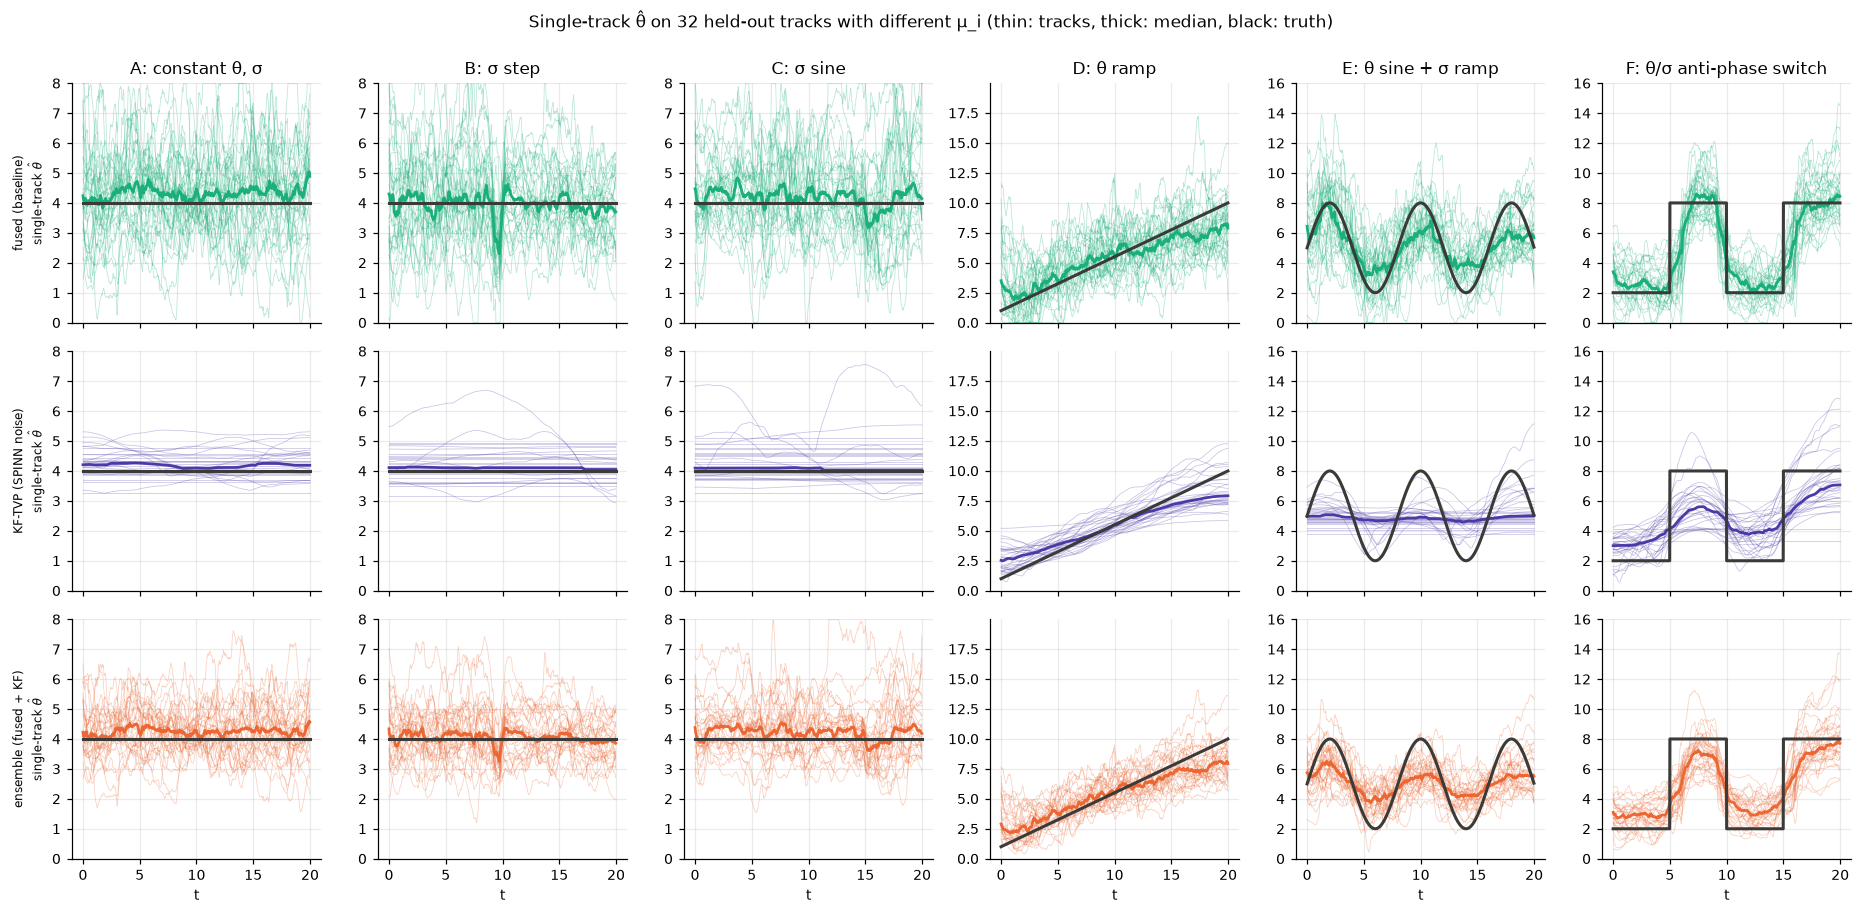

In [13]:
SHOW = [('融合 (基线)', '#1baf7a', 'fused (baseline)'),
        ('KF (SPINN 噪声)', '#4a3aa7', 'KF-TVP (SPINN noise)'),
        ('集成 (融合+KF)', '#eb6834', 'ensemble (fused + KF)')]
fig, axes = plt.subplots(len(SHOW), 6, figsize=(17, 2.75 * len(SHOW)), sharex=True)
for j, name in enumerate(names):
    truth = DATA[name]['theta']; ymax = 2.0 * truth.max()
    for i, (m, col, lab) in enumerate(SHOW):
        ax = axes[i, j]
        est = np.clip(EST[name][m], 0, ymax)
        ax.plot(t_grid, est.T, color=col, lw=0.5, alpha=0.3)
        ax.plot(t_grid, np.median(est, axis=0), color=col, lw=1.8)
        ax.plot(t_grid, truth, color=C_TRUE, lw=2)
        ax.set_ylim(0, ymax)
        if i == 0: ax.set_title(EN[name])
        if j == 0: ax.set_ylabel(f'{lab}\n' + r'single-track $\hat\theta$', fontsize=8)
        if i == len(SHOW) - 1: ax.set_xlabel('t')
fig.suptitle('Single-track θ̂ on 32 held-out tracks with different μ_i (thin: tracks, thick: median, black: truth)', y=1.0)
fig.tight_layout(); plt.show()

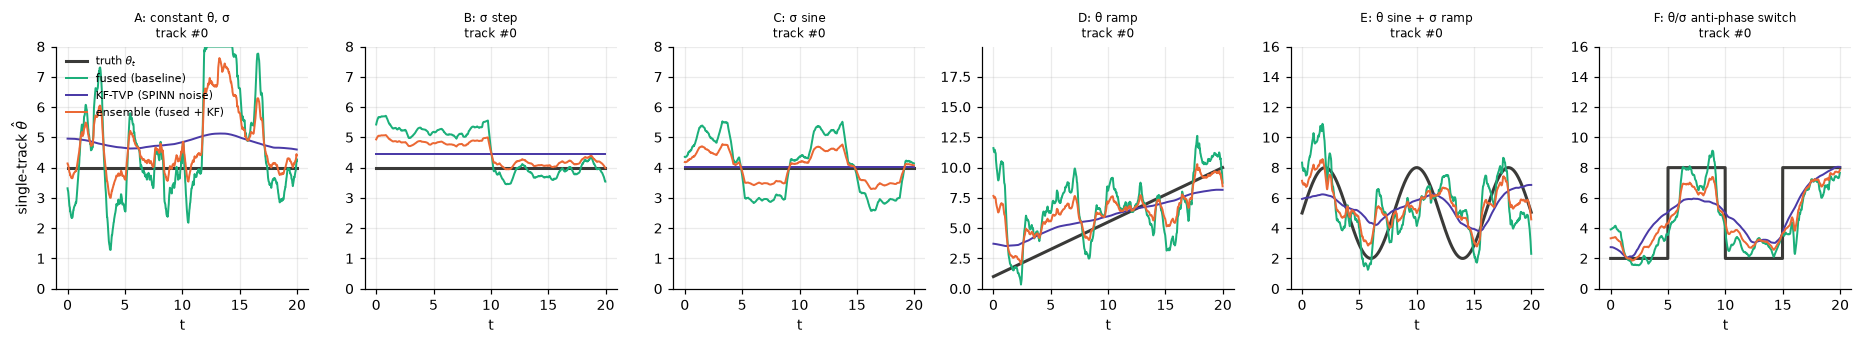

In [14]:
k = 0
fig, axes = plt.subplots(1, 6, figsize=(17, 3.2))
for ax, name in zip(axes, names):
    truth = DATA[name]['theta']; ymax = 2.0 * truth.max()
    ax.plot(t_grid, truth, color=C_TRUE, lw=2, label=r'truth $\theta_t$')
    for m, col, lab in SHOW:
        ax.plot(t_grid, np.clip(EST[name][m][k], 0, ymax), color=col, lw=1.3, label=lab)
    ax.set_ylim(0, ymax); ax.set_title(f'{EN[name]}\ntrack #{k}', fontsize=8); ax.set_xlabel('t')
axes[0].set_ylabel(r'single-track $\hat\theta$'); axes[0].legend(fontsize=7, loc='upper left')
fig.tight_layout(); plt.show()

## 6. 轨迹长度的影响

真实实验的轨迹往往更短。SPINN 的 regular / head 片段互不重叠，前 $T'$ 帧的 SPINN 输出只依赖于前 $T'$ 帧的数据，所以截断到前 $T'$ 帧与直接用长度为 $T'$ 的轨迹推断**完全等价**，不需要重新跑网络。下面比较 $T'\in\{300, 500, 1000\}$ 帧时各方法的 θ MRE（6 个情景平均）。

注意：截断后只评估前 $T'$ 帧，而各情景在前段的参数变化不同（例如 F 在 $t<5$ 时 $\theta$ 恒定），所以不同长度之间的数值不是严格可比的，重点看同一长度下各方法的相对排名。

In [15]:
LEN_METHODS = ['OLS', '融合 (基线)', 'KF (SPINN 噪声)', '集成 (融合+KF)']
len_rows = []
for Tp in [300, 500, 1000]:
    sl = slice(0, Tp)
    for name in names:
        X, v1, s1 = DATA[name]['X'][:, sl], RES[name]['v1'][:, sl], RES[name]['s1'][:, sl]
        th_t = DATA[name]['theta'][sl]
        sig = spinn_sigma(s1)
        est = {'OLS': k2theta(kendall(rolling_k(np.diff(X, axis=1, append=X[:, -1:]), X, 100), 100)),
               '融合 (基线)': k2theta(fused_k(X, v1, sig, 100))}
        QN = np.broadcast_to(Q_GRID[None, :, None], (N_EVAL, len(Q_GRID), Tp))
        est['KF (SPINN 噪声)'] = k2theta(kf_select(X, _roll(s1, 25), QN)[0])
        est['集成 (融合+KF)'] = 0.5 * (est['融合 (基线)'] + est['KF (SPINN 噪声)'])
        for m in LEN_METHODS:
            len_rows.append({'帧数': Tp, '情景': name, '方法': m,
                             'θ MRE': np.median(np.mean(np.abs(est[m] - th_t) / th_t, axis=1))})
len_df = pd.DataFrame(len_rows)
len_df.pivot_table(index='帧数', columns='方法', values='θ MRE', aggfunc='mean')[LEN_METHODS] \
      .style.format('{:.3f}').highlight_min(axis=1, color='#cde2fb')

方法,OLS,融合 (基线),KF (SPINN 噪声),集成 (融合+KF)
帧数,,,,
300,0.572,0.419,0.325,0.334
500,0.512,0.349,0.288,0.278
1000,0.452,0.314,0.248,0.250


## 7. 结论与建议

以下数字来自本 notebook 在 32 条独立测试轨迹（$\mu_i$ 各不相同）上的结果，SPINN 模型为 `SPINN_OU_demo.ipynb` 中 `QUICK = True`、`SEED = 0` 训练得到。

| 方法 | θ MRE（6 情景平均） | 擅长 | 短板 |
|---|---|---|---|
| 融合（基线，$W=100$） | 0.314 | 跟得上快速变化（E、F） | 单轨迹噪声大 |
| 融合 $W=200$ | 0.255 | 各情景普遍优于 $W=100$ | 窗口更大，对突变反应更慢 |
| KF-TVP（SPINN 噪声） | 0.248 | $\theta$ 恒定或缓慢变化（A–D 误差 0.08–0.24，D 趋势相关 0.98） | **E 中把正弦完全抹平成常数**，F 的切换幅度不足 |
| KF（SPINN 引导） | 0.242 | 比普通 KF 略好地跟随 F 的切换 | 总体提升很小，边际似然多数时候不选用引导项 |
| 集成（融合 + KF） | 0.250 | 最均衡：没有一个情景特别差，E 的趋势相关最高（0.64） | 恒定情景不如纯 KF |
| 集成（融合 $W=200$ + KF） | **0.228** | 平均误差最低，D 趋势相关 0.95 | $W=200$ 是在本测试集上挑的，结果偏乐观 |

**主要发现**

1. **最简单有效的改进是加大窗口**：融合方法从 $W=100$ 改为 $W=200$，平均误差从 0.314 降到 0.255。$W=300$ 在 E、F 上又变差，说明存在偏差与方差的平衡点，它取决于 $\theta_t$ 变化的时间尺度。
2. **卡尔曼平滑（KF-TVP）在 $\theta$ 慢变时最好**，而且平滑强度由每条轨迹自己的边际似然决定，不需要人为选窗口。但它有一个**危险的失效模式**：当 $\theta$ 振荡较快（E）时，似然更偏好“$\theta$ 为常数”，估计出一条平线，趋势完全丢失。用单轨迹找趋势时，这比噪声大更糟糕。
3. **SPINN 扩散估计作为观测噪声的价值**：只看平均误差，它与常数噪声相差不大；但在 $\sigma$ 变化剧烈的情景里差异明显：E 中与 $\sigma$ 的混淆从 0.68 降到 0.34，F 的趋势相关从 0.49 升到 0.76。
4. **用 SPINN 引导卡尔曼的过程噪声**（告诉它“什么时候在变”）基本无效。F 有小幅改善，其他情景几乎不变。
5. **集成平均最稳健**：融合与 KF 的误差来源互补，平均后在每个情景都不是最差，适合在事先不知道 $\theta_t$ 会怎样变化时使用。
6. **轨迹越短，优势越明显**：300 帧时，OLS、融合、KF、集成的平均误差分别为 0.57、0.42、0.33、0.33。短轨迹上 KF 和集成相对融合的改进更大。

**对真实实验的建议**

- 默认使用**集成（融合 + KF）**。如果 $\theta_t$ 的变化时间尺度比较长（远大于 $W\Delta$），可以把融合窗口加大到 200。
- 同时画出 KF 与融合两条单轨迹曲线：两者一致时结论可靠；**KF 平、融合在振荡**时，要警惕 KF 抹平了真实变化；**融合在动、KF 平且与 $\hat\sigma$ 同步**时，要警惕残余的 $\sigma$ 混淆。
- 所有方法都只用单条轨迹，不需要知道 $\mu_i$，也不需要跨轨迹平均。

**尚未尝试、值得继续的方向**

- **突变/变点模型**：例如交互多模型（IMM）卡尔曼、重尾过程噪声或 $\ell_1$ 趋势滤波，更适合 F 这种阶跃式变化；
- **按轨迹自动选择窗口 $W$**：例如用块交叉验证的一步预测似然；
- **改进 SPINN 本身**：目前 `DatasetTracks` 会去掉绝对位置，漂移网络只能从 50 帧历史中推断 $\mu$，这是漂移幅度被压缩的根源之一。给网络提供局部均值或更长的编码长度，可能从源头上减小偏差（需要重新训练）；
- **用多个随机种子和 `QUICK = False` 的完整训练重复本实验**，确认排名是否稳定。